In [16]:
from glob import glob
from langchain_classic import text_splitter
from langchain_core import documents
from openai.types import vector_store
from rich.jupyter import display

for g in glob('./data/*.csv'):
    print(g)

./data\detail_policy2_utf8.csv


In [17]:
from langchain_community.document_loaders import PyPDFLoader, CSVLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import pandas as pd
from langchain_core.documents import Document

# PDF 파일을 읽고 청크 단위로 텍스트를 잘라 리스트로 담아 반환
def read_pdf_and_split_text(pdf_path, chunk_size=1000, chunck_overlap=100):
    print(f'PDF: {pdf_path} ------')

    pdf_loader = PyPDFLoader(pdf_path)
    data_from_pdf = pdf_loader.load()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunck_overlap
    )

    splits = text_splitter.split_documents(data_from_pdf)

    print(f'Number of splits: {len(splits)}\n')

    return splits

# CSV 파일을 읽고 청크 단위로 텍스트를 잘라 리스트로 담아 반환
def read_csv_and_split_text(csv_path, chunk_size=1000, chunck_overlap=150):
    print(f'CSV: {csv_path} ------')
    df = pd.read_csv(csv_path)
    documents = []

    for index, row in df.iterrows():
        # 2. 메타데이터 구성 (필터링 및 식별 용도)
        # Chroma의 where 절에서 활용할 수 있도록 정형 데이터 위주로 지정합니다.
        metadata = {
            "service_id": str(row["서비스ID"]),
            "service_name": str(row["서비스명"]),
            "department": str(row["소관부처명"]),
            "year": int(row["기준연도"]) if pd.notnull(row["기준연도"]) else 0,
            "cycle": str(row["지원주기"]) if pd.notnull(row["지원주기"]) else "",
            "type": str(row["제공유형"]) if pd.notnull(row["제공유형"]) else "",
            "life_cycle": str(row["생애주기"]) if pd.notnull(row["생애주기"]) else "",
            "topic": str(row["관심주제"]) if pd.notnull(row["관심주제"]) else "",
            "household_type": str(row["가구유형"]) if pd.notnull(row["가구유형"]) else ""
        }

        # 3. 본문 텍스트 구조화 (벡터 검색 및 의미 파악 용도)
        # LLM과 임베딩 모델이 문맥을 이해하기 쉽도록 서술형 템플릿으로 재조합합니다.
        page_content = f"""
            [서비스명: {row['서비스명']}]
            소관부처: {row['소관부처명']}
            서비스 요약: {row['서비스요약']}

            # 대상자 상세 내용
            {row['대상자상세내용']}

            # 선정 기준 및 자격 요건
            {row['선정기준내용']}

            # 급여 및 서비스 내용 (지원 혜택)
            {row['급여서비스내용']}

            # 신청 절차 및 방법
            {row['신청절차']}

            # 안내 및 문의
            - 문의처: {row['문의처']}
            - 문의처 목록: {row['문의처목록']}
            - 홈페이지: {row['홈페이지목록']}
            - 근거 법령: {row['근거법령목록']}
        """

        # Document 객체 생성
        doc = Document(page_content=page_content.strip(), metadata=metadata)
        documents.append(doc)

    # 3. 긴 텍스트를 위한 Chunking 처리
    # 선정 기준이나 지원 내용이 매우 길기 때문에 벡터 DB의 한계를 넘지 않도록 분할
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunck_overlap,
        separators=["\n# ", "\n\n", "\n", " ", ""]
    )

    # 최종적으로 벡터 DB에 들어갈 청크 리스트
    split_docs = text_splitter.split_documents(documents)

    print(f'Number of splits: {len(split_docs)}\n')

    return split_docs

C:\Users\user\AppData\Local\Temp\ipykernel_26356\4122773043.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, CSVLoader


In [18]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
import os

# vectorstore 설정
embedding = OpenAIEmbeddings(
    base_url="http://localhost:1234/v1",
    model="text-embedding-bge-m3-ko",
    check_embedding_ctx_length=False
)

persist_directory='./chroma_store'

if os.path.exists(persist_directory):
    print("Loading existing Chroma store")
    vectorstore = Chroma(
        persist_directory=persist_directory,
        embedding_function=embedding
    )
else:
    print("Creating new Chroma Store")

    vectorstore = None
    for g in glob('./data/*.csv'):
        chunks = read_csv_and_split_text(g)
        # 100개씩 나눠서 저장
        for i in range(0, len(chunks), 100):
            if vectorstore is None:
                vectorstore = Chroma.from_documents(
                    documents=chunks[i:i+100],
                    embedding=embedding,
                    persist_directory=persist_directory
                )
            else:
                vectorstore.add_documents(
                    documents=chunks[i:i+100]
                )


# print("Creating new Chroma Store")
#
# vectorstore = None
# for g in glob('./data/*.csv'):
#     chunks = read_csv_and_split_text(g)
#     # 100개씩 나눠서 저장
#     for i in range(0, len(chunks), 100):
#         if vectorstore is None:
#             vectorstore = Chroma.from_documents(
#                 documents=chunks[i:i+100],
#                 embedding=embedding,
#                 persist_directory=persist_directory
#             )
#         else:
#             vectorstore.add_documents(
#                 documents=chunks[i:i+100]
#             )

Loading existing Chroma store


In [19]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

chunks = retriever.invoke("현금지급 지원")

for chunk in chunks:
    print(chunk.metadata)
    print(chunk.page_content)
    print("------------------")

{'type': '자원봉사, 프로그램/서비스(서비스), 현금지급, 현물지급, 현금대여(융자)', 'cycle': '년', 'life_cycle': '중장년, 영유아, 청년, 노년, 임신 · 출산, 아동, 청소년', 'year': 2026, 'topic': '서민금융', 'service_name': '자동차사고 피해자 지원사업', 'department': '국토교통부 자동차운영보험과', 'household_type': '장애인, 저소득', 'service_id': 'WLF00006298'}
# 선정 기준 및 자격 요건
            지원대상의 내용을 참고해주시기 바랍니다.

            # 급여 및 서비스 내용 (지원 혜택)
            자동차사고 피해자와 가족의 생활안정 및 자립지원을 위해 경제적정서적 지원 서비스를 제공합니다.
1. 경제적 지원

중증후유장애인 재활보조금 지원(22만원/월)
피부양가족 보조금 지원(22만원/월)
중증 후유장애인 및 유자녀 장학금 지원(분기 초등학생 25만원, 중학생 35만원, 고등학생 45만원/분기
유자녀 자립지원금: 월7만 / 유자녀
유자녀 무이자 생활자금 대출 지원(25만원/월)

2. 정서적 지원

심리상담 및 트라우마PTSD 치료지원
피해자 방문돌봄 및 생활지원
유자녀 학습진로 지원
간병간호 및 응급처치 교육 지원
주거환경 개선 및 응급안전 스마트홈 조성 지원
※ 지원내용 및 지원금액은 지원대상별 기준에 따라 상이할 수 있음

            # 신청 절차 및 방법
            1. 거주지 읍/면/동 주민센터, 자동차손해배상진흥원에서 ‘서비스 신청’
2. 담당 시/군/구청 또는 자동차손해배상진흥원에서 조사 및 심사
3. 담당 시/군/구청 또는 자동차손해배상진흥원에서 보장 결정
4. 담당 시/군/구청 또는 자동차손해배상진흥원에서 대상자에게 서비스 제공
5. 담당 시/군/구청 또는 자동차손해배상진흥원에서 서비스 제공 이후 대상자의 상황 관리

            # 안내 및 문의
 

여기까지가 벡터 DB 생성

In [20]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    base_url="http://localhost:1234/v1",
    model="google/gemma-4-e2b",
    api_key="lm-studio",
    temperature=0.7
)
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 만나서 반갑습니다. 😊\n\n저는 사용자님의 질문에 답하고, 정보를 제공하며, 다양한 작업을 도와드릴 수 있는 대규모 언어 모델입니다.\n\n궁금한 점이나 도움이 필요한 것이 있으시면 언제든지 말씀해주세요!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 18, 'total_tokens': 68, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'google/gemma-4-e2b', 'system_fingerprint': 'google/gemma-4-e2b', 'id': 'chatcmpl-gmnyk3jwz15d1xgu066ebi', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f34c7-d039-7e33-9873-a7a43125e172-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 50, 'total_tokens': 68, 'input_token_details': {}, 'output_token_details': {'reasoning': 0}})

In [21]:
# 라우터 설정
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal
from pydantic import BaseModel, Field

# Data Model
class RouteQuery(BaseModel):
    """사용자 쿼리를 가장 관련성이 높은 데이터 소스로 라우팅"""
    datasource: Literal["vectorstore", "casual_talk"] = Field(
        ...,
        description="""
        사용자 질문에 따라 casual_talk 또는 vectorstore로 라우팅합니다.
        - casual_talk: 일상 대화를 위한 데이터 소스, 사용자가 일상적인 질문을 할 때 사용됨
        - vectorstore: 사용자 질문에 답하기 위해 RAG로 vectorstore 검색이 필요한 경우 사용
        """
    )

In [37]:
# 특정 모델을 구조화된 출력과 함께 사용하기 위해서 설정
structured_llm_router = model.with_structured_output(RouteQuery)

router_system = """
    당신은 사용자의 질문을 분석하여 적절한 처리 노드로 분류하는 라우터입니다.
    다음 두 가지 카테고리 중 하나로만 분류하세요:
    1. vectorstore: 정부 지원, 복지 정책, 실업, 생활고, 금융 취약계층 지원 등 공공/민간 복지 서비스와 관련된 질문인 경우
    2. casual_talk: 일상적인 대화, 단순 인사, 복지 외 타 분야 질문인 경우

    [주의 사항]
    - 사용자가 '복지'나 '정책'이라는 단어를 직접 사용하지 않더라도, '실직', '퇴사', '생활비 부족', '파산', '취업 실패' 등 정부의 도움이나 지원 제도가 필요한 상황을 토로하는 경우반드시 WELFARE_POLICY로 분류해야 합니다.

    [예시]
    - "28세 남성인데 직장 짤렸는데 재취업이 너무 안돼서 파산 직전이야... 도움 받을 수 있는거 있을까?" -> vectorstore
    - "실업급여 신청 어떻게 해?" -> vectorstore
    - "요즘 날씨가 너무 좋네. 오늘 뭐하지?" -> casual_talk
    - "돈 많이 버는 법 알려줘" -> casual_talk

    [사용자 질문]
    "{question}"

    [출력 형식]
    텍스트 형태로 반환하세요: vectorstore 또는 casual_talk
"""

# 시스템 메시지와 사용자의 질문을 포함하는 프롬프트 템플릿 설정
route_prompt = ChatPromptTemplate.from_messages([
    ("system", router_system),
    ("human", "{question}"),
])

# 라우터 프롬프트와 구조화된 출력 모델을 결합한 객체
question_router = route_prompt | structured_llm_router

In [33]:
print(
    question_router.invoke({
        "question": "난 노인인데 내가 받을 수 있는 복지정책을 알려줘."
    })
)

print(
    question_router.invoke({
        "question": "잘 지냈어?"
    })
)

datasource='vectorstore'
datasource='casual_talk'


## 랭그래프로 RAG 에이전트 만들기

In [23]:
from langchain_core.prompts import PromptTemplate

class GradeDocuments(BaseModel):
    """검색된 문서가 질문과 관련성 있는 지 yes, no로 평가한다."""
    binary_score: Literal["yes", "no"] = Field(
        description="문서가 질문과 관련이 있는지 여부를 'yes' 또는 'no' 로 평가합니다."
    )

structured_llm_grader = model.with_structured_output(GradeDocuments)

In [24]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

def expand_query(query: str, n: int = 3) -> list[str]:
    """LLM으로 쿼리를 확장합니다."""
    llm = ChatOpenAI(
        base_url="http://localhost:1234/v1",
        model="google/gemma-4-e2b",
        api_key="lm-studio",
        temperature=0.7
    )
    prompt = ChatPromptTemplate.from_template(
        "다음 질문에 대해 의미는 같지만 표현이 다른 검색 쿼리를 "
        "{n}개 생성하세요. 각 쿼리를 줄바꿈으로 구분하세요.\n\n"
        "원본 질문: {query}"
    )
    response = llm.invoke(prompt.format(query=query, n=n))
    expanded = response.content.strip().split("\n")
    return [q.strip() for q in expanded if q.strip()][:n]

In [25]:
def trim_question(question: str):
    llm = ChatOpenAI(
        base_url="http://localhost:1234/v1",
        model="google/gemma-4-e2b",
        api_key="lm-studio",
        temperature=0.7
    )
    prompt = ChatPromptTemplate.from_template(
        f"""
            당신은 복지 정책 추천 시스템의 데이터 전처리 및 질의 분석(Query Analyzer) 에이전트입니다.
            사용자의 자연어 질문을 분석하여, 사전에 정의된 메타데이터 필터링 조건들을 추출하고, 벡터 검색에 사용할 핵심 질문(search_query)을 분리하여 반드시 JSON 형식으로만 반환하십시오.

            [메타데이터 추출 기준 및 필드명]
            아래 명시된 필드에 해당하는 조건이 질문에 포함되어 있다면 추출하십시오. 언급되지 않은 조건은 반드시 null로 처리하여 임의로 추론하지 마십시오.
            W
            1. "year" (정수형): 질문에서 특정 연도를 묻는 경우 추출 (예: "2026년 정책" -> 2026)
            2. "department" (문자열): 소관부처명 (예: "국토부", "국토교통부", "복지부" 등)
            3. "cycle" (문자열): 지원주기 (예: "1회성", "월별", "연간" 등)
            4. "type" (문자열): 제공유형 (예: "현물지급", "현금지급", "서비스" 등)
            5. "life_cycle" (문자열): 생애주기 (예: "영유아", "청년", "중장년", "노년" 등)
            6. "topic" (문자열): 관심주제 (예: "주거", "일자리", "건강", "교육" 등)
            7. "household_type" (문자열): 가구유형 (예: "저소득", "한부모", "다문화", "1인가구" 등)

            [추가 추출 필드]
            8. "search_query" (문자열): 메타데이터 필터를 제외하고, 벡터 DB에서 의미 유사도 검색을 수행할 때 사용할 핵심 질문 사항. 필터 조건이 제거된 깔끔한 문장이나 키워드로 구성하십시오.

            [출력 형식 제한]
            부연 설명 없이 오직 유효한 JSON 객체만 반환하십시오.

            [예시 1]
            사용자 질문: "2026년도 국토교통부에서 하는 청년 주거 지원 사업 중에 현금으로 주는 거 있어?"
            출력:
              "year": 2026,
              "department": "국토교통부",
              "cycle": null,
              "type": "현금지급",
              "life_cycle": "청년",
              "topic": "주거",
              "household_type": null,
              "search_query": "지원 사업 상세 조건 및 혜택"


            [예시 2]
            사용자 질문: "저소득 한부모 가족이 받을 수 있는 임대주택 자산 기준이 어떻게 돼?"
            출력:
              "year": null,
              "department": null,
              "cycle": null,
              "type": null,
              "life_cycle": null,
              "topic": "주거",
              "household_type": "저소득, 한부모",
              "search_query": "임대주택 자산 기준 및 신청 자격"
            \n\n

            "원본 질문: {question}"
        """
    )
    response = llm.invoke(prompt.format(query=question))
    return response.text

In [26]:
# 기존 대화 내용이 계속 이어질 필요가 없는 경우: PromptTemplate
# 이어질 필요가 있는 경우: ChatPromptTemplate
grader_prompt = ChatPromptTemplate.from_template("""
    당신은 검색된 문서가 사용자 질문과 최소한의 연관성이라도 갖추고 있는지 판별하는 1차 필터링 에이전트입니다.
    당신의 유일한 목표는 질문과 완전히 무관한 '쓰레기 문서(Garbage)'를 제거하는 것입니다.

    [이진 평가 기준]
    1. 문서의 내용이 질문의 핵심 주제나 맥락을 일부라도 다루고 있다면 'yes'를 부여하십시오. (완벽한 정답이 아니어도 통과)
    2. 질문과 우연히 겹치는 단어가 존재하더라도, 문서의 전체적인 주제가 질문의 의도와 완전히 다르다면 'no'를 부여하십시오.
    3. 문서가 질문에 대답하는 데 1%의 도움이라도 될 여지가 있다면 보수적으로 'yes'로 평가하여 문서를 살려두십시오.

    Retrieved document:
    {document}

    User question: {question}
""")

retrieval_grader = grader_prompt | structured_llm_grader

In [45]:
question = "지원주기가 년 단위인 정책"
documents = retriever.invoke(question)

for doc in documents:
    print(doc)


page_content='# 선정 기준 및 자격 요건
            지원대상의 내용을 참고해주시기 바랍니다.

            # 급여 및 서비스 내용 (지원 혜택)
            자동차사고 피해자와 가족의 생활안정 및 자립지원을 위해 경제적정서적 지원 서비스를 제공합니다.
1. 경제적 지원

중증후유장애인 재활보조금 지원(22만원/월)
피부양가족 보조금 지원(22만원/월)
중증 후유장애인 및 유자녀 장학금 지원(분기 초등학생 25만원, 중학생 35만원, 고등학생 45만원/분기
유자녀 자립지원금: 월7만 / 유자녀
유자녀 무이자 생활자금 대출 지원(25만원/월)

2. 정서적 지원

심리상담 및 트라우마PTSD 치료지원
피해자 방문돌봄 및 생활지원
유자녀 학습진로 지원
간병간호 및 응급처치 교육 지원
주거환경 개선 및 응급안전 스마트홈 조성 지원
※ 지원내용 및 지원금액은 지원대상별 기준에 따라 상이할 수 있음

            # 신청 절차 및 방법
            1. 거주지 읍/면/동 주민센터, 자동차손해배상진흥원에서 ‘서비스 신청’
2. 담당 시/군/구청 또는 자동차손해배상진흥원에서 조사 및 심사
3. 담당 시/군/구청 또는 자동차손해배상진흥원에서 보장 결정
4. 담당 시/군/구청 또는 자동차손해배상진흥원에서 대상자에게 서비스 제공
5. 담당 시/군/구청 또는 자동차손해배상진흥원에서 서비스 제공 이후 대상자의 상황 관리

            # 안내 및 문의
            - 문의처: 1544-0049
            - 문의처 목록: 자동차사고 피해자 지원사업 콜센터: 1544-0049
            - 홈페이지: 자동차사고 피해자 지원사업 홈페이지: https://tvsis.tacss.or.kr/tvsis/main.do
            - 근거 법령: 자동차손해배상 보장법' metadata={'life_cycle': '중장년, 영유아, 청년, 노년, 임신 · 출산, 아동, 청소년', 'hous

In [27]:
from langchain_classic.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever

# 1. 키워드 검색기(BM25) 설정
bm25_retriever = BM25Retriever.from_documents(chunks)
bm25_retriever.k = 3

# 2. 벡터 검색기(Chroma) 설정
chroma_retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# 3. 하이브리드 앙상블 검색기 생성 (가중치를 5:5로 설정)
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, chroma_retriever],
    weights=[0.5, 0.5]
)

# 4. 통합 검색 실행
query = "28세 남성인데 직장 짤렸는데 재취업이 너무 안돼서 파산 직전이야... 도움 받을 수 있는거 있을까?"
hybrid_results = ensemble_retriever.invoke(query)

for doc in hybrid_results:
    print(f" 검색 결과: {doc.metadata['service_name']}")

 검색 결과: 생활안정자금(융자)(이차보전)
 검색 결과: 자동차사고 피해자 지원사업
 검색 결과: 개인회생 파산 종합지원(지원센터)
 검색 결과: 요실금 치료지원 사업
 검색 결과: 법률구조


In [40]:
filtered_docs = []

for i, doc in enumerate(documents):
    print(f"Document {i + 1}")
    is_relevant = retrieval_grader.invoke({"question": question, "document": doc.page_content})
    print(is_relevant)
    print(doc.page_content[:200])
    print("========================\n\n")

    if is_relevant.binary_score == "yes":
        filtered_docs.append(doc)

print(f"Filtered documents: {len(filtered_docs)}")

Document 1
binary_score='yes'
# 선정 기준 및 자격 요건
            지원대상의 내용을 참고해주시기 바랍니다.

            # 급여 및 서비스 내용 (지원 혜택)
            자동차사고 피해자와 가족의 생활안정 및 자립지원을 위해 경제적정서적 지원 서비스를 제공합니다.
1. 경제적 지원

중증후유장애인 재활보조금 지원(22만원/월)
피부양가족 보조금


Document 2
binary_score='no'
[서비스명: 안부살핌 우편서비스 사업]
            소관부처: 행정안전부 복지자원연계팀
            서비스 요약: 1인 가구 증가, 사회적 관계망 약화 등 사회적 고립가구에 대한 선제적 발굴을 통한 신속한 대응과 지원으로 촘촘한 복지안전망을 구축하고자 합니다.

            # 대상자 상세 내용
            중장년층 1인


Document 3
binary_score='yes'
# 선정 기준 및 자격 요건
            지원대상의 내용을 참고해주시기 바랍니다.

            # 급여 및 서비스 내용 (지원 혜택)
            지원 대상자는 요실금 치료 후 우선 의료기관에 의료비를 납부하고, 처방전영수증진료비 상세내역서 등 의료비 청구를 위해 필요한 구비서류 발급 요청
청구된 의료비 중 지원 범위에 해당하


Document 4
binary_score='no'
# 급여 및 서비스 내용 (지원 혜택)
            방문형, 통원형(집단 프로그램) 등의 직접 서비스(안전지원, 사회참여, 생활교육, 일상생활지원) 및 연계 서비스(민간후원 자원), 특화서비스, 사후관리서비스를 제공합니다.
개인별 돌봄욕구, 필요정도에 따라 서비스 내용, 제공시간, 제공주기 등을 결정합니다.

            # 신청 절차 


Document 5
binary_score='no'
# 선정 기준 및 자격 요건
            일반공급 선정기준은다음과 같습니다.

In [40]:
rag_generate_system = """
너는 사용자의 질문에 대해 주어진 documents 에 기반하여 답변하는 복지 정책 전문가이다.
주어진 documents 를 기반으로 사용자의 question에 대해 답변하라.

===================================
question: {question}
documents: {documents}
"""

rag_prompt = PromptTemplate(
    input_variables=["question", "documents"],
    template=rag_generate_system
)

# rag chain
rag_chain = rag_prompt | model

In [39]:
question = "28세 남성인데 직장 짤렸는데 재취업이 너무 안돼서 파산 직전이야... 도움 받을 수 있는거 있을까?"

rag_chain.invoke({"question": question, "documents": hybrid_results})

AIMessage(content='사용자님의 어려운 상황에 대해 안타까움을 표하며, 주어진 문서를 기반으로 도움을 받을 수 있는 정책 및 서비스에 대해 안내해 드리겠습니다.\n\n현재 직장 상실과 재취업의 어려움으로 인해 파산 직전의 상황이라면, 채무 문제 해결과 생계 안정을 위한 법률적·금융적 지원을 우선적으로 고려하시는 것이 중요합니다.\n\n주어진 문서들을 바탕으로 도움을 받을 수 있는 주요 서비스는 다음과 같습니다.\n\n### 1. 개인회생 및 파산 제도 이용 지원 (채무 해결)\n\n경제적인 어려움으로 인해 채무를 감당하기 어려운 경우, 법률 구조와 제도를 통해 도움을 받을 수 있습니다.\n\n*   **서비스명:** 개인회생 파산 종합지원(지원센터)\n    *   **소관 부처:** 법무부 인권구조과\n    *   **주요 내용:** 감당할 수 없는 빚으로 인해 **개인회생, 개인파산 및 면책 제도** 이용을 원하는 국민을 지원합니다.\n    *   **지원 내용:** 개인 회생 및 개인 파산 사건에 대한 법률 상담 및 소송 대리 등 법률 구조를 지원하며, 신청 절차 전반에 걸친 지원을 제공합니다.\n\n*   **서비스명:** 법률구조\n    *   **소관 부처:** 법무부 인권구조과\n    *   **주요 내용:** 경제적으로 어렵거나 법률 지식이 부족하여 법의 보호를 받지 못하는 국민에게 법률상담, 소송 대리 등의 서비스를 지원합니다.\n    *   **지원 내용:** 개인회생·파산 신청 사건 등 관련 법률 서비스 및 소송 대리 등을 지원받을 수 있습니다.\n\n### 2. 일자리 및 생활안정자금 관련 지원 (재취업 및 금융 지원)\n\n직장 상실과 관련된 상황이나 재정적 부담 완화를 위한 자금 지원 관련 정보도 참고하실 수 있습니다.\n\n*   **서비스명:** 생활안정자금(융자)(이차보전)\n    *   **소관 부처:** 고용노동부 퇴직연금복지과\n    *   **주요 내용:** 근로자, 특수형태근로종사자 등이 혼례, 

# 그래프 정의하기

In [7]:
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    question: str # 사용자 질문
    generation: str # LLM 생성 결과
    documents: List[str]

In [1]:
def route_question(state):
    """
    사용자 질문을 vectorstore 또는 casual_talk으로 라우팅한다.

    :param
        state (dict): 현재 graph state
    :return:
        state (dict): 라우팅된 데이터 소스와 사용자 질문을 포함하는 새로운 graph state
    """
    print("------ ROUTE ------")
    question = state['question']
    route = question_router.invoke({"question": question})

    print(f"--- Routing to {route.datasource} ---")
    return route.datasource

In [28]:
def retrieve(state):
    """
    vectorstore에서 질문에 대한 문서를 검색한다.

    :param
        state (dict): 현재 graph state
    :return:
        state (dict): 검색된 문서와 사용자 질문을 포함하는 새로운 graph state
    """
    print("------ RETRIEVE ------")
    question = state['question']

    #Retrieve documents
    documents = ensemble_retriever.invoke(question)
    return {"documents": documents, "question": question}

In [3]:
def grade_documents(state):
    """
    검색된 문서를 평가하여 질문과 관련성이 있는 지 확인한다.

    :param
        state (dict): 현재 graph state
    :return:
        state (dict): 관련성이 있는 문서와 사용자 질문을 포함하는 새로운 graph state
    """
    print("------ GRADE ------")
    question = state['question']
    documents = state['documents']
    filtered_docs = []

    for i, doc in enumerate(documents):
        is_relevant = retrieval_grader.invoke({"question": question, "documents": doc.page_content})
        if is_relevant.binary_score == "yes":
            filtered_docs.append(doc)

    return {"documents": filtered_docs, "question": question}

In [44]:
def generate(state):
    """
    LLM을 사용하여 문서와 사용자 질문에 대한 답변을 생성한다.

    :param
        state (dict): 현재 graph state
    :return:
        state (dict): LLM 생성 결과와 사용자 질문을 포함하는 새로운 graph state
    """
    print("------ GENERATE ------")
    question = state['question']
    documents = state['documents']
    generation = rag_chain.invoke({"question": question, "documents": documents})

    return {
        "documents": documents,
        "question": question,
        "generation": generation
    }

In [5]:
def casual_talk(state):
    """
    일상 대화를 위한 답변을 생성합니다.

    :param
        state (dict): 현재 graph state
    :return:
        state (dict): 일상 대화 결과와 사용자 질문을 포함하는 새로운 graph state
    """
    print("------ CASUAL TALK ------")
    question = state['question']
    generation = model.invoke(question)

    return {
        "question": question,
        "generation": generation
    }

## StateGraph 만들기

In [46]:
from langgraph.graph import START, StateGraph, END

workflow = StateGraph(GraphState)

In [47]:
# 노드를 정의
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("casual_talk", casual_talk)

In [48]:
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "vectorstore": "retrieve",
        "casual_talk": "casual_talk"
    }
)
workflow.add_edge("casual_talk", END)
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

app = workflow.compile()

#

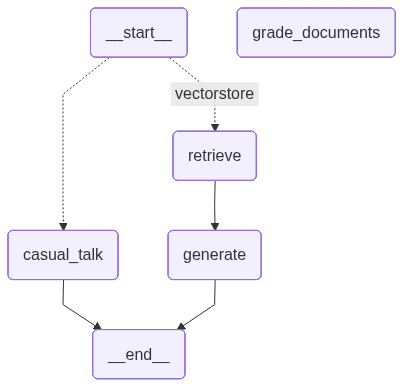

In [49]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # 실패 시 통과
    pass

In [50]:
inputs = {
    "question": "28세 남성인데 직장 짤렸는데 재취업이 너무 안돼서 파산 직전이야... 도움 받을 수 있는거 있을까?"
}
app.invoke(inputs) # workflow를 실행

------ ROUTE ------
--- Routing to vectorstore ---
------ RETRIEVE ------
------ GENERATE ------


{'question': '28세 남성인데 직장 짤렸는데 재취업이 너무 안돼서 파산 직전이야... 도움 받을 수 있는거 있을까?',
 'generation': AIMessage(content='제공해주신 정보를 바탕으로 현재 상황에 도움을 받을 수 있는 관련 정책 및 서비스에 대해 안내해 드리겠습니다.\n\n사용자님께서 직장 문제와 재취업의 어려움으로 인해 파산 직전에 계시므로, 채무 및 생활 안정을 위한 법률적 지원과 금융 지원 방안을 중심으로 관련 정보를 확인해 보시는 것이 필요합니다.\n\n주어진 문서를 기반으로 확인 가능한 도움은 다음과 같습니다.\n\n### 1. 개인회생 및 파산 관련 법률 구조 지원\n경제적으로 어려운 상황에서 채무 문제 해결을 위해 법적인 절차를 진행하는 데 필요한 지원을 받을 수 있습니다.\n\n*   **서비스명:** 개인회생 파산 종합지원(지원센터) (ID: 0a017b92-840c-4bf5-b292-be366faf4415)\n*   **주요 내용:** 감당할 수 없는 빚으로 인해 개인회생, 개인파산 및 면책 제도를 이용하고자 하는 국민을 대상으로 법률 상담 및 소송 대리 등 법률 구조를 지원합니다.\n*   **지원 범위:** 변호사에 의한 신청 대리, 변호사 보수 및 인지대, 송달료 무료 지원 등을 포함하며, 소득 기준 등에 따라 비용 지원 여부가 달라질 수 있습니다.\n*   **신청 절차:** 거주지 읍/면/동 주민센터 또는 대한법률구조공단 개인회생·파산 종합지원센터를 통해 신청할 수 있습니다.\n\n### 2. 일자리 및 재직 관련 금융 지원\n근로자 및 자영업자의 생활 안정을 위한 대출 이자 보전 등의 금융 지원 제도가 있습니다.\n\n*   **서비스명:** 생활안정자금(융자)(이차보전) (ID: 60cc49a8-41fa-48ef-a427-d74c59816e4c)\n*   **주요 내용:** 근로자 등이 혼례, 자녀 양육 등을 대출할 때, 대출 이자의 일부를 근로복지공단이 지원하여 금융 부담을 완화합니다. (다만,

In [51]:
inputs = {
    "question": "잘 지냈어?"
}
app.invoke(inputs) # workflow를 실행

------ ROUTE ------
--- Routing to casual_talk ---
------ CASUAL TALK ------


{'question': '잘 지냈어?',
 'generation': AIMessage(content='네, 저는 잘 지냈어요. 😊\n\n당신은요? 요즘 어떻게 지내셨어요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 393, 'prompt_tokens': 21, 'total_tokens': 414, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 367, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'google/gemma-4-e2b', 'system_fingerprint': 'google/gemma-4-e2b', 'id': 'chatcmpl-9rue2z6fkitxi4a5v1zcc', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f34e6-1f93-7f51-b1d2-271272ad0321-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 21, 'output_tokens': 393, 'total_tokens': 414, 'input_token_details': {}, 'output_token_details': {'reasoning': 367}})}